# Etapa 2 | Modelagem
## N.O.V.A | Classificação de qualidade de frutas

## Objetivo



A etapa anterior definiu a base final com 8.115 registros únicos, retirou Light das features, manteve Temp, Humid e CO2 e estabeleceu quatro classificadores especializados, um para cada fruta.

Esta etapa treina e avalia os quatro modelos XGBoost e ao final, exporta os modelos que serão utilizados pelo protótipo.

Os modelos treinados serão utilizados pelo micro-serviço N.O.V.A. Como apoio ao monitoramento preventivo das condições de armazenamento de frutas.

## Setup

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from xgboost import XGBClassifier

## Preparação do Dataset



O tratamento aplicado aqui reproduz as decisões fechadas na EDA. O alvo será mapeado como Good = 0 e Bad = 1.

In [2]:
dados = pd.read_csv(Path("../dataset/dataset_frutas.csv"))
dados["Class"] = dados["Class"].str.strip().str.title()

colunas_sensores = ["Temp", "Humid (%)", "Light (Fux)", "CO2 (pmm)"]
colunas_registro = ["Fruit", *colunas_sensores, "Class"]

dados = (
    dados
    .drop_duplicates(subset=colunas_registro, keep="first")
    .copy()
)

features = ["Temp", "Humid (%)", "CO2 (pmm)"]
mapa_alvo = {"Good": 0, "Bad": 1}

dados["target"] = dados["Class"].map(mapa_alvo)

composicao = pd.crosstab(dados["Fruit"], dados["Class"])
composicao["Total"] = composicao.sum(axis=1)

display(composicao)

Class,Bad,Good,Total
Fruit,,,
Banana,430,838,1268
Orange,1129,1309,2438
Pineapple,779,811,1590
Tomato,1208,1611,2819


## Divisão entre treino e teste



Para cada fruta, 80% dos dados serão usados no treinamento e 20% no teste.

In [3]:
RANDOM_STATE = 42
ordem_frutas = ["Banana", "Orange", "Pineapple", "Tomato"]

splits = {}
resumo_split = []

for fruta in ordem_frutas:
    dados_fruta = dados[dados["Fruit"] == fruta]

    X = dados_fruta[features]
    y = dados_fruta["target"]

    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )

    splits[fruta] = {
        "X_treino": X_treino,
        "X_teste": X_teste,
        "y_treino": y_treino,
        "y_teste": y_teste
    }

    resumo_split.append({
        "Fruta": fruta,
        "Treino": len(X_treino),
        "Teste": len(X_teste),
        "Good treino (%)": (y_treino == 0).mean() * 100,
        "Bad treino (%)": (y_treino == 1).mean() * 100,
        "Good teste (%)": (y_teste == 0).mean() * 100,
        "Bad teste (%)": (y_teste == 1).mean() * 100
    })

display(
    pd.DataFrame(resumo_split)
    .set_index("Fruta")
    .round(2)
)

,Treino,Teste,Good treino (%),Bad treino (%),Good teste (%),Bad teste (%)
Fruta,,,,,,
Banana,1014,254,66.07,33.93,66.14,33.86
Orange,1950,488,53.69,46.31,53.69,46.31
Pineapple,1272,318,51.02,48.98,50.94,49.06
Tomato,2255,564,57.16,42.84,57.09,42.91


É perceptível a diferença de dados entre as classes, com o caso de maior desbalanceamento sendo o de Banana, tendo somente 33.86% dos dados de treino e teste como Bad. Em razão disso, como idealmente o objetivo é o modelo ter um bom desempenho em ambas as classificações, a métrica principal a ser utilizada pra validação será o F1 macro, pois ele dará um peso igualitário ao desempenho de Good e Bad.

Além disso, as proporções de cada classe serão mantidas entre treino, validação cruzada (folds) e teste, a fim de evitar que as métricas calculadas recebam uma distribuição muito diferente.

## Configuração do XGBoost



A EDA mostrou fronteiras simples entre alguns sensores e a classe. Em razão disso, a modelagem não exige um ajuste profundo de hiperparâmetros.

In [4]:
xgb_params = {
    "n_estimators": 100,
    "max_depth": 2,
    "learning_rate": 0.1,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

## Validação Cruzada



Será utilizada validação cruzada K-fold (5 folds) e F1 macro.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_cv = []

for fruta in ordem_frutas:
    split = splits[fruta]
    modelo = XGBClassifier(**xgb_params)

    scores = cross_val_score(
        modelo,
        split["X_treino"],
        split["y_treino"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=1
    )

    linha = {"Fruta": fruta}

    for i, score in enumerate(scores, start=1):
        linha[f"Fold {i}"] = score

    linha["Média"] = scores.mean()
    linha["Desvio"] = scores.std()

    resultados_cv.append(linha)

tabela_cv = (
    pd.DataFrame(resultados_cv)
    .set_index("Fruta")
)

display(tabela_cv.round(4))

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Média,Desvio
Fruta,,,,,,,
Banana,0.9890,1.0000,0.9945,1.0000,0.9889,0.9945,0.0049
Orange,0.9201,0.8994,0.8969,0.9122,0.9145,0.9086,0.0090
Pineapple,1.0000,0.9922,1.0000,0.9961,1.0000,0.9976,0.0031
Tomato,0.9797,0.9751,0.9887,0.9864,0.9730,0.9806,0.0061


Percebe-se que os resultados tem desempenho muito alto e com baixa variação entre os folds. Banana e Pineapple chegam ao valor máximo de F1 macro em algumas divisões, o que chama atenção (negativamente).

Essas métricas altas (somadas aos desvios muito baixos) reforçam a alta facilidade na separabilidade dos dados demonstrada na EDA. Mesmo alterando as observações utilizadas em cada fold, os resultados continuam próximos da perfeição (com exceção de Orange), o que indica que as fronteiras simples se repetem em diferentes subconjuntos do dataset.

Entretanto, Orange apresenta um desempenho mais plausível, com média de ≈91%. Algo pertinente a notar é que na EDA, a variável Light separava completamente Good e Bad para essa fruta. Como essa feature foi removida, isso ajuda a explicar por que o modelo para Orange não acompanha os resultados quase perfeitos dos modelos das outras frutas.

## Avaliação no teste



Os quatro modelos serão treinados com a mesma configuração utilizada na validação cruzada e avaliados pelo F1 macro no conjunto de teste, o que nos permite comparar diretamente os resultados das duas etapas.

In [6]:
modelos = {}
resultados_f1_teste = []

for fruta in ordem_frutas:
    split = splits[fruta]

    modelo = XGBClassifier(**xgb_params)
    modelo.fit(split["X_treino"], split["y_treino"])

    pred_teste = modelo.predict(split["X_teste"])

    modelos[fruta] = modelo

    resultados_f1_teste.append({
        "Fruta": fruta,
        "F1 macro teste": f1_score(
            split["y_teste"],
            pred_teste,
            average="macro"
        )
    })

tabela_f1_teste = (
    pd.DataFrame(resultados_f1_teste)
    .set_index("Fruta")
)

display(tabela_f1_teste.round(4))

,F1 macro teste
Fruta,
Banana,0.9868
Orange,0.9072
Pineapple,0.9969
Tomato,0.9659


Como se pode observar, o teste reproduz o mesmo comportamento da validação cruzada. Não existe uma relevante queda nas métricas entre as duas. Logo, não há evidências de overfitting.

Na realidade, o problema é outro, pois Banana e Pineapple (principalmente) continuam muito próximas de um desempenho perfeito. Isso reforça ainda mais o que já havia sido discutido anteriormente, que as fronteiras dessas frutas são simples até demais, facilitando e muito o trabalho do XGBoost.

Porém, essa estabilidade nas métricas é interna. Ela mostra que os modelos se comportam de forma consistente com dados presentes no dataset, mas não é uma garantia de que o mesmo resultado "perfeito" ocorrerá com leituras coletadas em produção.

## Precisão e Recall



O F1 macro mostra o desempenho entre Good e Bad, porém não descreve a direção dos erros e acertos dos modelos. Em razão disso, Precisão e Recall serão utilizados para identificar como está ocorrendo essa distribuição de predições.

In [7]:
resultados_classes = []

for fruta in ordem_frutas:
    split = splits[fruta]
    modelo = modelos[fruta]

    pred_teste = modelo.predict(split["X_teste"])

    precisao, recall, _, _ = precision_recall_fscore_support(
        split["y_teste"],
        pred_teste,
        labels=[0, 1],
        zero_division=0
    )

    for classe, p, r in zip(["Good", "Bad"], precisao, recall):
        resultados_classes.append({
            "Fruta": fruta,
            "Classe": classe,
            "Precisão": p,
            "Recall": r
        })

tabela_classes = (
    pd.DataFrame(resultados_classes)
    .set_index(["Fruta", "Classe"])
)

display(tabela_classes.round(4))

Precisão  Recall
Fruta     Classe                  
Banana    Good      0.9882  0.9940
          Bad       0.9882  0.9767
Orange    Good      0.9094  0.9198
          Bad       0.9058  0.8938
Pineapple Good      0.9939  1.0000
          Bad       1.0000  0.9936
Tomato    Good      0.9967  0.9441
          Bad       0.9305  0.9959

Para 3/4 das frutas, Precisão e Recall ficam muito próximos. A exceção a isso é Tomato, onde existe uma inversão óbvia entre as classes. Enquanto Bad apresenta Recall praticamente máximo, porém Precisão significativamente menor. Em Good ocorre o contrário, com Precisão próxima do máximo e Recall  significativamente menor.

Isso implica que o modelo de Tomato tende a deslocar parte dos registros Good para Bad. Como consequência disso, quase nenhum caso realmente Bad passa como Good, porém alguns Good recebem um rótulo de Bad.



## Matrizes de confusão



As matrizes decompõem os resultados obtidos em Precisão e Recall, mostrando a distribuição dos acertos e erros no conjunto de teste númericamente.

In [8]:
def plot_matriz_confusao(fruta):
    split = splits[fruta]
    modelo = modelos[fruta]

    ConfusionMatrixDisplay.from_estimator(
        modelo,
        split["X_teste"],
        split["y_teste"],
        display_labels=["Good", "Bad"],
        values_format="d",
        cmap="Reds"
    )

    plt.title(f"Matriz de confusão | {fruta}")
    plt.tight_layout()
    plt.show()

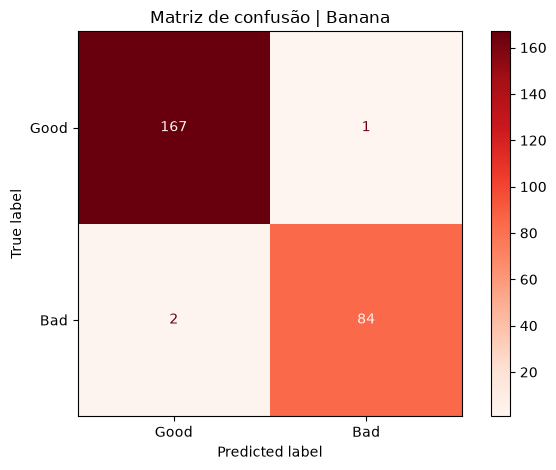

In [9]:
plot_matriz_confusao("Banana")

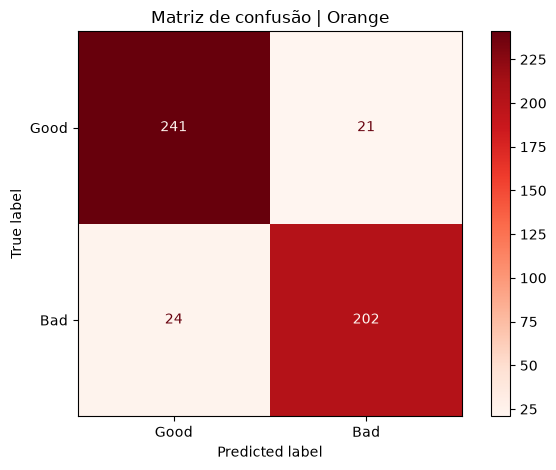

In [10]:
plot_matriz_confusao("Orange")

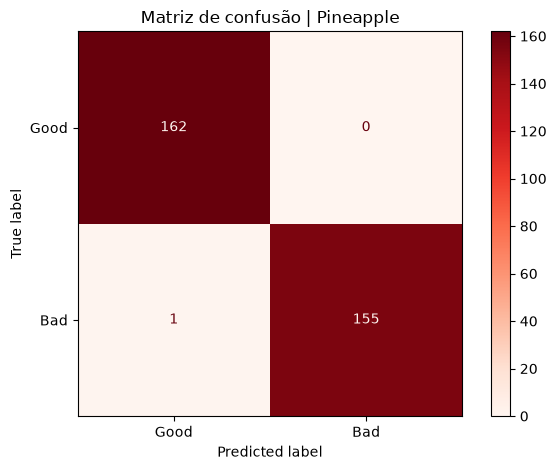

In [11]:
plot_matriz_confusao("Pineapple")

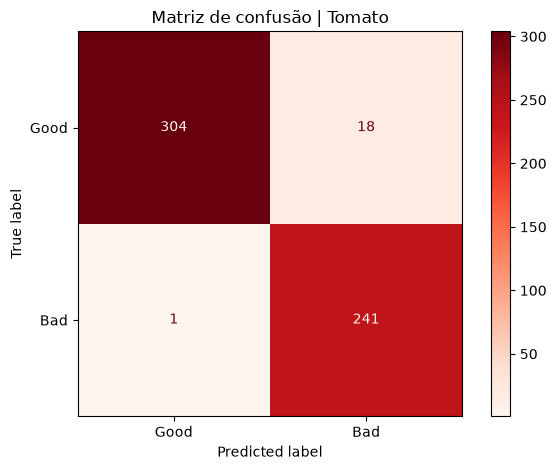

In [12]:
plot_matriz_confusao("Tomato")

Pode-se observar que os números confirmam a assimetria em Tomato discutida anteriormente. Entre os 19 erros do modelo, 18 são rótulos Good classificados como Bad e apenas 1 caso ocorre no sentido contrário. Sendo assim, a matriz de confusão evidencia numericamente algo que já havia sido indicado pela Precisão e pelo Recall, que o modelo de Tomato é conservador em classificar Bad como Good.

Para o protótipo esse comportamento não é necessariamente ruim, pois reduz o risco de ignorar condições ruins para a fruta. Porém, isso ocorre ao custo de classificar certas condições consideradas ideais como sendo desfavoráveis.

Em relação aos modelos das outras frutas, como Precisão e Recall não apresentam uma assimetria tão discrepante, o resultado disso é uma distribuição de erros quase simétrica para Good e Bad. O que, em termos práticos, significa modelos sem um viés explícito para uma classe específica.

## Permutation Importance



Depois que os modelos foram treinados e testados, surgiu a pergunta: "quais sensores realmente sustentam seu desempenho e como isso se compara à informação mútua encontrada na EDA ?"

Para respondê-la, será utilizada a Permutation Importance, medindo quanto o F1 macro cai quando os valores de cada feature são embaralhados.

In [13]:
importancias_permutacao = []

for fruta in ordem_frutas:
    split = splits[fruta]
    modelo = modelos[fruta]

    resultado = permutation_importance(
        modelo,
        split["X_teste"],
        split["y_teste"],
        scoring="f1_macro",
        n_repeats=20,
        random_state=RANDOM_STATE
    )

    for feature, media, desvio in zip(
        features,
        resultado.importances_mean,
        resultado.importances_std
    ):
        importancias_permutacao.append({
            "Fruta": fruta,
            "Feature": feature,
            "Importância média": media,
            "Desvio": desvio
        })

df_permutacao = pd.DataFrame(importancias_permutacao)

In [14]:
def plot_permutacao(fruta):
    dados_plot = (
        df_permutacao[df_permutacao["Fruta"] == fruta]
        .sort_values("Importância média")
    )

    plt.figure(figsize=(7, 4))
    plt.barh(
        dados_plot["Feature"],
        dados_plot["Importância média"],
        xerr=dados_plot["Desvio"]
    )
    plt.xlabel("Queda média no F1 macro")
    plt.title(f"Permutation importance | {fruta}")
    plt.tight_layout()
    plt.show()

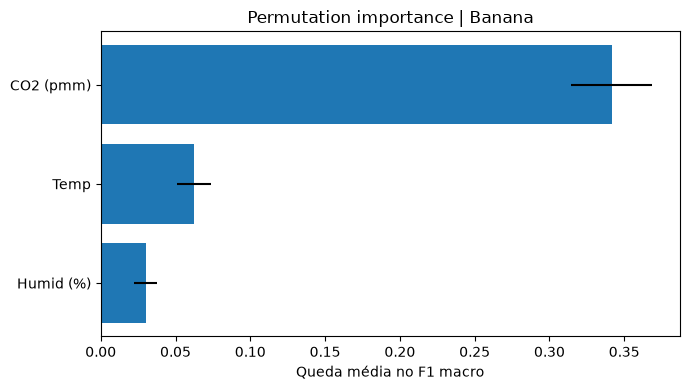

In [15]:
plot_permutacao("Banana")

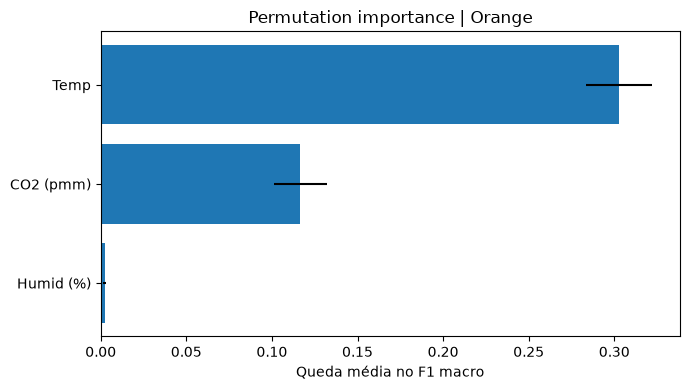

In [16]:
plot_permutacao("Orange")

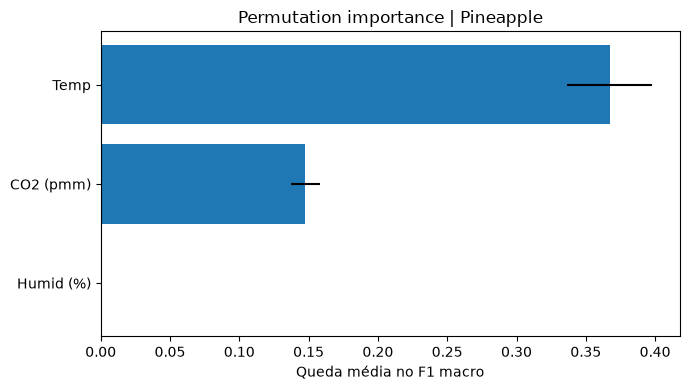

In [17]:
plot_permutacao("Pineapple")

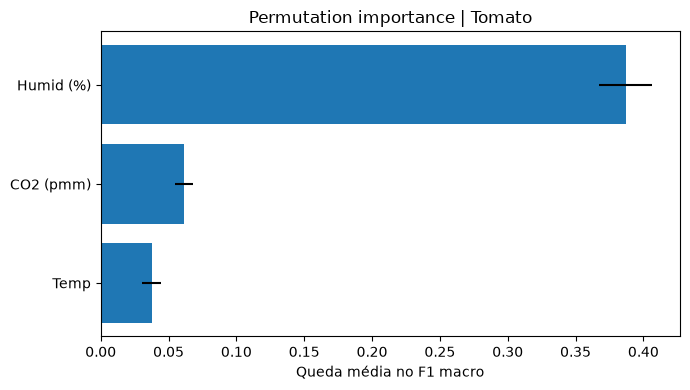

In [18]:
plot_permutacao("Tomato")

Os resultados respondem a pergunta, o sensor principal permanece o mesmo que a informação mútua havia apontado nas quatro frutas. Isso enfatiza a decisão tomada na EDA de utilizar classificadores especializados, já que cada fruta continua dependendo de uma estrutura diferente dos sensores.

Em contraste, os sensores nas outras posições do ranking mudam de ordem em Banana e Tomato. Isso não é tão inesperado, pois a informação mútua e a Permutation Importance observam as variáveis de formas diferentes.

Em direção a isso, o XGBoost utiliza as features em conjunto. Caso duas variáveis carreguem parte de uma mesma informação, uma delas pode ser utilizada primeiro pelas árvores e reduzir a informação restante que a outra conseguiria acrescentar. Da mesma forma, ao embaralhar uma dessas features na Permutation Importance, parte de sua contribuição ainda pode estar representada por outra feature, fazendo com que a queda no desempenho seja menor.

Logo, uma feature muito informativa de forma isolada não necessariamente manterá a mesma importância depois que passa a atuar em conjunto com as demais.

## Reajuste dos modelos finais



Cada modelo será treinado uma última vez com todos os dados da sua respectiva fruta, reunindo treino e teste para gerar o modelo final que vai pra integração com o Stockly.

In [19]:
modelos_finais = {}

for fruta in ordem_frutas:
    dados_fruta = dados[dados["Fruit"] == fruta]

    X_final = dados_fruta[features]
    y_final = dados_fruta["target"]

    modelo_final = XGBClassifier(**xgb_params)
    modelo_final.fit(X_final, y_final)

    modelos_finais[fruta] = modelo_final

## Exportação dos modelos

In [24]:
pasta_modelos = Path("../../modelo_classificacao/modelos")
pasta_modelos.mkdir(exist_ok=True)

arquivos_modelos = {}

for fruta, modelo in modelos_finais.items():
    nome_arquivo = f"xgb_{fruta.lower()}.json"
    caminho = pasta_modelos / nome_arquivo

    modelo.save_model(caminho)
    arquivos_modelos[fruta] = nome_arquivo

    print(f"Salvo em {caminho}")

metadata = {
    "features": features,
    "target": mapa_alvo,
    "models": arquivos_modelos
}

caminho_metadata = pasta_modelos / "metadata.json"

with open(caminho_metadata, "w", encoding="utf-8") as arquivo:
    json.dump(metadata, arquivo, ensure_ascii=False, indent=2)

print(f"Salvo em {caminho_metadata}")

Salvo em ../../modelo_classificacao/modelos/xgb_banana.json
Salvo em ../../modelo_classificacao/modelos/xgb_orange.json
Salvo em ../../modelo_classificacao/modelos/xgb_pineapple.json
Salvo em ../../modelo_classificacao/modelos/xgb_tomato.json
Salvo em ../../modelo_classificacao/modelos/metadata.json


## Custo dos sensores e escalabilidade



As features dos quatro classificadores dependem de 2 sensores, que serão utilizados em produção. O DHT22 fornece Temp (temperatura) e Humid (umidade), enquanto o MG811 fornece CO2 (dióxido de carbono).

Com base na pesquisa feita pelos projetistas de hardware do projeto, os valores foram considerados R\$ 28.69 (média)  para o DHT22 e R\$ 419.90 (média) para o MG811.

Fontes: [DHT22](https://www.mercadolivre.com.br/up/MLBU790882854?matt_tool=38524122&pdp_filters=item_id:MLB696375585&ua=KuHqFzrIk0yRGewZE7m0zu1cQHaxkIeiXUZsTuy3MAybG42j#origin=share&sid=share&wid=MLB696375585&action=copy) e [MG811](https://www.smartkits.com.br/sensor-de-dioxido-de-carbono-co2-mg811).

In [21]:
precos = {
    "DHT22": 28.69,
    "MG811": 419.90
}

total_sensores = sum(precos.values())

custos_sensores = pd.DataFrame({
    "Sensor": ["DHT22", "MG811", "Total"],
    "Leituras": ["Temp + Humid", "CO2", ""],
    "Custo por ponto (R$)": [
        precos["DHT22"],
        precos["MG811"],
        total_sensores
    ],
    "Participação no custo (%)": [
        precos["DHT22"] / total_sensores * 100,
        precos["MG811"] / total_sensores * 100,
        100
    ]
})

display(
    custos_sensores
    .set_index("Sensor")
    .round(2)
)

,Leituras,Custo por ponto (R$),Participação no custo (%)
Sensor,,,
DHT22,Temp + Humid,28.69,6.4
MG811,CO2,419.90,93.6
Total,,448.59,100.0


O MG811 representa 93.6% do custo dos sensores em cada ponto de monitoramento. Em comparação, o DHT22 fornece duas features por uma parcela pequena do valor total. Somado a isso, conforme aumenta o número de pontos de monitoramento, fica claro que o MG811 se torna o principal gargalo de custo relacionado aos sensores.

Apesar desse problema, não sustenta-se a retirada desse sensor apenas por economia. Pois o CO2 é a feature mais importante de Banana e ainda contribui para os demais classificadores.

Portanto, os dois sensores serão mantidos no projeto. Porém, é importante notar que para uma futura expansão, deve-se priorizar a busca e validação de sensores mais baratos para medir o CO2. Caso uma alternativa consiga manter a qualidade das leituras e o desempenho dos modelos, a Stockly poderá reduzir de forma significativa o crescimento dos custos conforme aumenta o número de pontos de monitoramento em um supermercado.

## Limitações do projeto




Os resultados muito altos encontrados principalmente em Banana, Pineapple e Tomato precisam ser interpretados junto com o que foi observado na EDA.

Pois algumas dessas frutas possuem fronteiras muito simples entre sensores e classe, fazendo com que o próprio dataset favoreça classificações próximas da perfeição. Sendo assim, essas métricas demonstram que o XGBoost aprendeu facilmente os padrões presentes nesses dados, mas ainda não dizem como os modelos irão se comportar quando receberem medições reais vindas dos sensores nos supermercados.

Ademais, como treino e teste foram separados a partir do mesmo dataset, representam o mesmo processo de coleta. Sendo assim, os modelos não foram testados em situações de novas condições de armazenamento mais diversas, outros lotes de frutas ou ruídos nas leituras dos sensores utilizados pela Stockly. Logo, a principal validação para os modelos é utilizar dados coletados diretamente pelo DHT22 e MG811 e avaliar como se comportam os resultados.


## Conclusão



A modelagem reforçou a decisão tomada na EDA de utilizar classificadores especializados por fruta. O sensor mais informativo permaneceu diferente entre elas e coincidiu com o observado pela informação mútua, mostrando que essa diferença não desapareceu quando as features passaram a atuar em conjunto nos modelos.

Os resultados também confirmaram que parte do alto desempenho está relacionada à própria estrutura dos dados. Pineapple e Banana mantiveram métricas próximas da perfeição mesmo na validação cruzada e no teste. Em oposição a isso, Orange apresentou um resultado mais plausível. Como consequência disso, as métricas demonstram boa estabilidade interna, mas não podem ser interpretadas como garantia de desempenho em operação real.

Para o protótipo, DHT22 e MG811 serão mantidos. Apesar do MG811 concentrar quase a totalidade do custo dos sensores, CO2 ainda possui importância suficiente para justificar sua utilização. Sendo assim, a principal etapa seguinte é validar os modelos com medições reais nos supermercados e em paralelo, investigar alternativas mais baratas para CO2 sem comprometer o desempenho.

Por fim, caso ocorra uma perda significativa de desempenho dos modelos em produção, será necessário recalibrá-los, realizar um novo treinamento ou, em último caso, optar pela descontinuação desse serviço.